#### SVM-nin tətbiqi - Quadratic Programming ilə optimizasiya, λ görə təsnif, from sklearn import svm

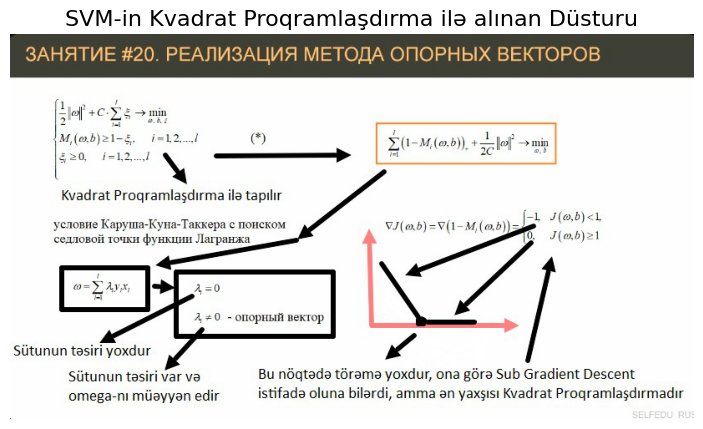

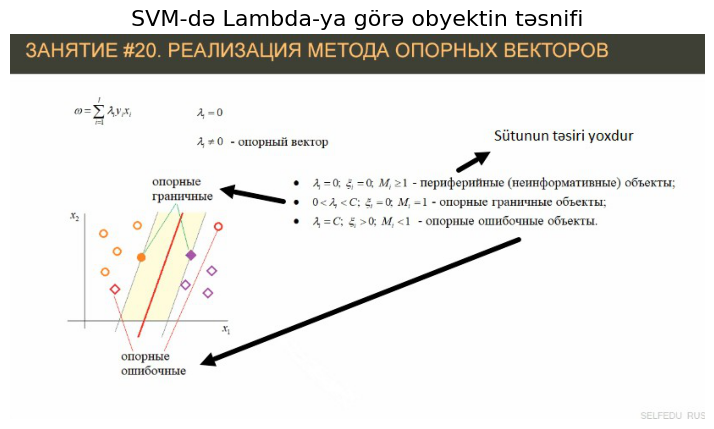

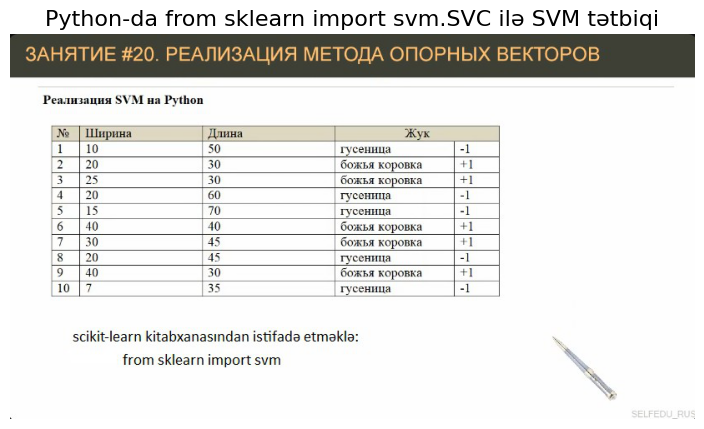

In [6]:
from PIL import Image

# Fayl yolunun əsas hissəsi
base_path = r'C:\Users\dell\Desktop\Selfedu\Pictures\ML_20_'

# Şəkilləri saxlayacağımız siyahı
image_list = []

# 1-dən 5-ə qədər olan şəkilləri dövr ilə açırıq
for i in range(1, 4):  # 1-dən 5-ə qədər
    full_path = f'{base_path}{i}.jpg'  # Fayl yolunu dinamik olaraq yaradırıq
    img = Image.open(full_path)
    image_list.append(img)  # Şəkili siyahıya əlavə edirik

# Nəticə: images siyahısında bütün yüklənmiş şəkillər olacaq

import matplotlib.pyplot as plt

# Şəkilləri göstərin
for i, image in enumerate(image_list):
    if i == 100:
        plt.figure(figsize=(8.8, 4))          
    else:     
        plt.figure(figsize=(25, 5))  # Şəkilin ölçüsü    
        
    if i < 1:
        plt.title("""SVM-in Kvadrat Proqramlaşdırma ilə alınan Düsturu""", size='16')
    elif i < 2:
        plt.title("""SVM-də Lambda-ya görə obyektin təsnifi""", size='16')  
    elif i < 3:
        plt.title("""Python-da from sklearn import svm.SVC ilə SVM tətbiqi""", size='16')         
        
    plt.imshow(image)
    plt.axis('off')  # Oxları gizlətmək üçün
    plt.show()


#### Python-da `from sklearn import svm.SVC`, yəni SVM Model Quadratic Programming ilə optimallaşdırma edib $\quad$ $\quad$ $\omega$ və $b$-ni hesablayır

w - coef_ omegas və b: 
[ 0.24431486 -0.13072144  0.00635516]

w_1: 0.24431486, w_2: -0.13072144,  b: 0.00635516 
 Ayırıcı Xətt düsturu: 0.24431486 x1 -0.13072144 x2 + 0.00635516

v (support_vectors with coordinates): 
 [[20. 45.  1.]
 [20. 30.  1.]
 [30. 45.  1.]]


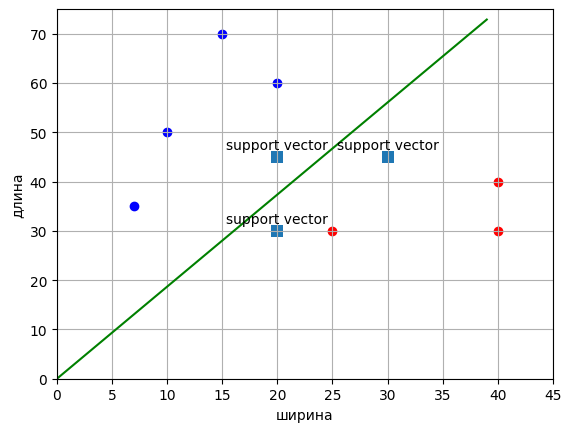

In [37]:
# NumPy kitabxanasını idxal edirik ki, massivlər və riyazi əməliyyatlarla rahat işləyə bilək
import numpy as np
# Qrafik çəkmək üçün matplotlib-in pyplot modulunu idxal edirik
import matplotlib.pyplot as plt
# SVM modelləri üçün sklearn kitabxanasından svm modulunu idxal edirik
from sklearn import svm


# Təlim datası yaradılır; hər nümunə iki xüsusiyyətə malikdir (məsələn, uzunluq və genişlik)
x_train = [[10, 50], [20, 30], [25, 30], [20, 60], [15, 70], [40, 40], [30, 45], [20, 45], [40, 30], [7, 35]]
# Hər nümunəyə bias (sabit) əlavə olunur ki, ayırıcı xətt `w*x + b = 0` şəklində ifadə olunsun
x_train = [x + [1] for x in x_train]
# Hər nümunə üçün sinif etiketi təyin olunur (-1 və 1), SVM bu etikətlərə görə öyrənəcək
y_train = [-1, 1, 1, -1, -1, 1, 1, -1, 1, -1]


# Xətti kernel istifadə edən SVC modeli yaradılır; bu model dayaq vektorlarını tapmaq üçün istifadə olunur
clf = svm.SVC(kernel='linear')
# SVC modeli təlim datası ilə öyrədilir və dayaq vektorlarını seçir
clf.fit(x_train, y_train)

# LinearSVC modeli yaradılır; məqsəd çəkilər (w vektorunu) daha sürətli və sabit hesablamaqdır
lin_clf = svm.LinearSVC()
# LinearSVC modeli də təlim datası ilə öyrədilir, w vektoru LinearSVC-dən alınacaq
lin_clf.fit(x_train, y_train)

# SVC tərəfindən seçilmiş dayaq vektorları götürülür; bu nöqtələr qərar sərhədini müəyyən edir
v = clf.support_vectors_
# LinearSVC tərəfindən öyrənilmiş çəkilər (w vektoru) götürülür, ayırıcı xətt üçün lazımdır
w = lin_clf.coef_[0]
# w vektoru və dayaq vektorları ekrana çap olunur ki, nəticələri yoxlayaq
print(f'w - coef_ omegas və b: \n{w}', 
      f'w_1: {w[0]:.8f}, w_2: {w[1]:.8f},  b: {w[2]:.8f} \n Ayırıcı Xətt düsturu: {w[0]:.8f} x1 {w[1]:.8f} x2 + {w[2]:.8f}',  
      f'v (support_vectors with coordinates): \n {v}', sep='\n\n')


# Təlim datası NumPy massivinə çevrilir ki, hesablama və seçmələr rahat olsun
x_train = np.array(x_train)
# Sinif etiketləri də NumPy massivinə çevrilir
y_train = np.array(y_train)
# Ayırıcı xətti çəkmək üçün x oxu üzrə nöqtələr yaradılır (x qiymətləri)
line_x = list(range(max(x_train[:, 0])))
# Ayırıcı xəttin y koordinatları w vektoruna əsasən hesablanır: `y = -w0/w1 * x - b/w1`
line_y = [-x*w[0]/w[1] - w[2] for x in line_x]


# 1 sinfinə aid nöqtələr seçilir ki, qrafikdə fərqli rənglə göstərək
x_0 = x_train[y_train == 1]
# -1 sinfinə aid nöqtələr seçilir
x_1 = x_train[y_train == -1]


# 1 sinfinə aid nöqtələr qırmızı ilə qrafikdə göstərilir
plt.scatter(x_0[:, 0], x_0[:, 1], color='red')
# -1 sinfinə aid nöqtələr mavi ilə göstərilir
plt.scatter(x_1[:, 0], x_1[:, 1], color='blue')
# Dayaq vektorları xüsusi markerlə vurğulanır, SVM-in əhəmiyyətli nümunələrini göstərir
plt.scatter(v[:, 0], v[:, 1], s=70, edgecolor=None, linewidths=0, marker='s')
# Dayaq vektorları üzərində Support Vector yazılsın
for i in range(len(v)):
    plt.text(v[i,0], v[i,1] + 1, 'support vector', ha='center', va='bottom')
# Hesablanmış ayırıcı xətt qrafikdə yaşıl xəttlə çəkilir
plt.plot(line_x, line_y, color='green')


# X oxunun sərhədləri təyin olunur ki, qrafik oxuna sığsın
plt.xlim([0, 45])
# Y oxunun sərhədləri təyin olunur
plt.ylim([0, 75])
# Y oxuna başlıq verilir
plt.ylabel("длина")  # uzunluq
# X oxuna başlıq verilir
plt.xlabel("ширина")  # genişlik
# Qrafikdə tor görünməsi aktiv edilir ki, oxları daha rahat oxuya bilək
plt.grid(True)
# Qrafik ekranda göstərilir
plt.show()

### İki nümunə əlavə olunur ki Data Xətti Ayrılmayan olsun:
- $[30, 10]$ $\quad$ $[-1]$ Class-ı üçün hansı ki əslində $[10, 30]$ kimi olmalıdı idi
- $[15, 50]$  $\quad$ $[1]$ Class-ı üçün hansı ki əslində $[50, 15]$ kimi olmalıdı idi
- Ancaq `svm.SVC(kernel='linear')` istifadə olunur
- For Linearly Non-Separable olduğu üçün `svm.LinearSVC()` istifadə olunmur

Loss: [-2  2  0  0  0  0  0  0  0  0  0  0]

 v (support_vectors with coordinates): 
 [[30. 10.  1.]
 [20. 60.  1.]
 [20. 45.  1.]
 [ 7. 35.  1.]
 [15. 50.  1.]
 [20. 30.  1.]
 [25. 30.  1.]
 [30. 45.  1.]]


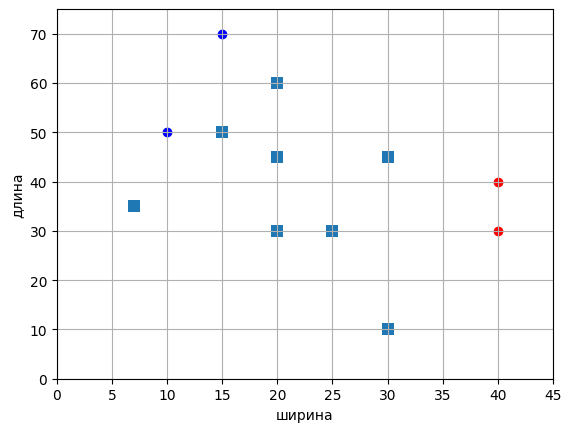

In [4]:
# NumPy kitabxanasını idxal edirik. Bu, massivlər və riyazi əməliyyatlar üçün istifadə olunacaq.
import numpy as np
# Matplotlib kitabxanasının pyplot modulunu idxal edirik. Bu, qrafiklər çəkmək üçün istifadə olunacaq.
import matplotlib.pyplot as plt
# Scikit-learn kitabxanasından SVM (Dəstək Vektor Maşını) modulunu idxal edirik.
from sklearn import svm

# --- Təlim Datasının Hazırlanması ---
# Hər bir nümunə iki xüsusiyyətdən ibarətdir (məsələn, en və uzunluq). Bu, ilkin təlim siyahısıdır.
x_train = [[30, 10], [15, 50], [10, 50], [20, 30], [25, 30], [20, 60], [15, 70], [40, 40], [30, 45], [20, 45], [40, 30], [7, 35]]
# Hər bir nümunəyə sabit bir ədəd (bias) olan '1' əlavə edirik. 
# Bunun səbəbi, ayırıcı xətt tənliyini (w1*x1 + w2*x2 + b = 0) avtomatik olaraq ifadə edə bilməkdir.
# Yəni w vektorumuz [w1, w2, b] şəklində olacaq.
x_train = [x + [1] for x in x_train]
# Hər bir nümunəyə aid sinif etiketlərini təyin edirik. SVM modelimiz iki sinfi (-1 və 1) bir-birindən ayıracaq.
y_train = [-1, 1, -1, 1, 1, -1, -1, 1, 1, -1, 1, -1]

# --- Modelin Qurulması və Təlimi (SVC) ---
# Xətti kernel istifadə edən SVC (C-Support Vector Classification) modeli yaradılır.
clf = svm.SVC(kernel='linear')
# Model təlim məlumatları (x_train və y_train) ilə öyrədilir. Bu prosesdə model ən uyğun ayırıcı xətti və dəstək vektorlarını tapır.
clf.fit(x_train, y_train)

# --- Modelin Qiymətləndirilməsi ---
# Öyrədilmiş modeldən istifadə edərək, eyni təlim nümunələrinin siniflərini təxmin edirik.
y_pr = clf.predict(x_train)
# Təxmin edilən siniflərlə həqiqi siniflər arasındakı fərqi çap edirik.
# Çıxış sıfırdırsa, təxmin düzgündür. Sıfırdan fərqli dəyərlər səhv təsnifatı göstərir.
print(f'Loss: {np.array(y_train) - np.array(y_pr)}')  

# --- Dəstək Vektorlarının Tapılması ---
# Model tərəfindən tapılan dəstək vektorlarını alırıq. Bu nöqtələr ayırıcı xəttin mövqeyini müəyyən edən ən kritik nümunələrdir.
v = clf.support_vectors_
# Dəstək vektorlarının koordinatlarını çap edirik.
print(f'\n v (support_vectors with coordinates): \n {v}')

# --- Qrafikin Çəkilməsi Üçün Hazırlıq ---
# Təlim datasını və etiketlərini NumPy massivinə çeviririk. Bu, qrafik çəkərkən indeksləmə və hesablamalar aparmağı asanlaşdırır.
x_train = np.array(x_train)
y_train = np.array(y_train)

# Sinif etiketi 1 olan nöqtələri seçirik. (Qırmızı rənglə göstəriləcək)
x_0 = x_train[y_train == 1]
# Sinif etiketi -1 olan nöqtələri seçirik. (Mavi rənglə göstəriləcək)
x_1 = x_train[y_train == -1]

# --- Qrafikin Çəkilməsi ---
# 1-ci sinfə aid nöqtələri qırmızı rəngdə səpələyirik.
plt.scatter(x_0[:, 0], x_0[:, 1], color='red')
# -1-ci sinfə aid nöqtələri mavi rəngdə səpələyirik.
plt.scatter(x_1[:, 0], x_1[:, 1], color='blue')
# Dəstək vektorlarını kvadrat işarə (marker='s') ilə və daha böyük ölçüdə (s=70) vurğulayırıq ki, qrafikdə asan seçilsin.
plt.scatter(v[:, 0], v[:, 1], s=70, edgecolor=None, linewidths=0, marker='s')

# Qrafikin X oxunun görünən sahəsini 0-dan 45-ə qədər məhdudlaşdırırıq.
plt.xlim([0, 45])
# Qrafikin Y oxunun görünən sahəsini 0-dan 75-ə qədər məhdudlaşdırırıq.
plt.ylim([0, 75])
# Y oxuna "uzunluq" etiketini əlavə edirik.
plt.ylabel("длина")  # uzunluq
# X oxuna "en" etiketini əlavə edirik.
plt.xlabel("ширина")  # genişlik
# Qrafikdə şəbəkə xətlərini aktivləşdiririk ki, oxunuş asan olsun.
plt.grid(True)
# Hazırlanmış qrafiki ekranda göstəririk.
plt.show()

### Bu Mövzunun əsas Düsturu

$$\omega = \sum_{i=1}^l \lambda_i y_i x_i$$


Qısa izah:

- $ \omega $ — **ayırıcı hiper müstəvinin çəki vektoru. $x_i$ vektorlarının xətti kombinasiyası şəklində ifadə olunub.**
- $ l $ — **təlim nümunələrinin sayı**
- $ \lambda_i $ — **Lagrange multiplikatoru - Support Vector olub-olmadığını müəyyən edir. Optimallaşdırılan dəyişən.**
- $ y_i $ — **obyektin sinif etiketi $(+1, -1)$**
- $ x_i $ — **i-ci obyektin **xüsusiyyət vektoru**, əgər $ \lambda_i > 0 $ olarsa həmin obyekt **Support Vector** olur.**

**Məna:**
> $ \omega $ **təlim obyektlərinin xətti kombinasiyasıdır və real olaraq **yalnız support vectorlar** hiper müstəvini müəyyən edir.**

### Lambda-ya görə obyektin təsnifi - $C$ və $λ$ nədir?

$$
\omega = \sum_{j=1}^{l} \lambda_i y_i x_i
$$

**Ümumi izah (C və λ nədir):**

- **C** — tənzimləmə parametri.  
  **Böyük C** → səhvlərə cəza böyük, Margin dar, Model mürəkkəb.  
  **Kiçik C** → səhvlərə tolerant, Margin geniş, Model sadə.  
  `λ ≤ C` şərti ilə məhdudlaşdırıcı rol oynayır.
$$$$
- **λᵢ** — Laqranj çarpanı.  
- `λ=0` → təsirsiz; 
- `0<λ<C` → Margin üzərində dayaq vektor;
- `λ=C` → məhdudiyyətə çatmış, səhv və ya Margin daxili nöqtə.

---

**1. Şərt:**  
$$
\lambda_i = 0; \quad \xi_i = 0; \quad M_i \geq 1
$$ 
- **Nəticə:** **Periferik (informativ olmayan) obyektlər**. **Təsirsiz** 
- **İzah:**  
>  **`λ=0` olduğu üçün bu obyektlər qərara təsir etmir. Düzgün tərəfdə və Margin xaricində yerləşir.**

---

**2. Şərt:**  
$$
0 < \lambda_i < C; \quad \xi_i = 0; \quad M_i = 1
$$
- **Nəticə:** **Dayaq sərhəd (support boundary) obyektlər**.  **Sərhəd təyin edən** (Margin üzərində)
- **İzah:**  
> **`λ` sıfırdan böyük, C-dən kiçikdir. `ξ=0` olduğu üçün xəta yoxdur, Margin üzərindədir. Marginı təyin edən əsas vektorlardır.**

---

**3. Şərt:**  
$$
\lambda_i = C; \quad \xi_i > 0; \quad M_i < 1
$$  
- **Nəticə:** **Dayaq səhv (support error) obyektlər**. **Səhv və ya Margin daxili** (cəzalandırılan).
- **İzah:**  
> **`λ=C` (maksimum cəza dəyəri) və `ξ>0` (Margin daxilində və ya yanlış tərəfdə). Modelin xəta etdiyi və ya Marginə sığmayan nümunələrdir.**

### Quadratic Programming - qsa məlumat

Qısa izah:

* **Quadratic Programming (QP)** — məqsəd funksiyası **kvadrat**, məhdudiyyətlər isə **xətti** olan optimallaşdırma məsələsidir.

SVM-də də:

* Məqsəd funksiyası: $ \frac{1}{2}||\omega||^2 $ → **kvadratdır**
* Məhdudiyyətlər: $ y_i(\omega^T x_i + b) \ge 1 $ → **xəttidir**

Ona görə **SVM problemi riyaziyyatda Quadratic Programming problemi kimi formalaşır.**


#### Lagrange multiplikatorları metodu və ikili (dual) formaya keçid - Kvadrat Proqramlaşdırma



#### 1. İlkin (primal) məsələ:  
$$
\begin{cases}
\frac{1}{2}||\omega||^2 + C \sum\limits_{i=1}^{l} \xi_i \rightarrow 
\min\limits_{\omega,b,\xi} \\
M_i(\omega,b) \ge 1-\xi_i \\
\xi_i \ge 0
\end{cases}
$$

#### 2. Laqranj funksiyası qurulur:
$$
\mathcal{L} = \frac12 \|\omega\|^2 + C\sum_{i=1}^{l} \xi_i - \sum_{i=1}^{l} \lambda_i (y_i(\omega\cdot x_i + b) - 1 + \xi_i) - \sum_{i=1}^{l} \beta_i \xi_i
$$

#### 3. 
$\frac{\partial \mathcal{L}}{\partial \omega} = 0$ $\quad$ şərtindən $\omega = \sum_\limits{i=1}^{l} \lambda_i y_i x_i$ alınır.  
 
$$$$
Beləliklə:  

$$
\omega = \sum_{j=1}^{l} \lambda_i y_i x_i
$$

Qısa izah:

- $ \omega $ — **ayırıcı hiper müstəvinin çəki vektoru. $x_i$ vektorlarının xətti kombinasiyası şəklində ifadə olunub.**
- $ l $ — **təlim nümunələrinin sayı**
- $ \lambda_i $ — **Lagrange multiplikatoru (Support Vector olub-olmadığını müəyyən edir). Optimallaşdırılan dəyişən.**
- $ y_i $ — **obyektin sinif etiketi $(+1, -1)$**
- $ x_i $ — **i-ci obyektin **xüsusiyyət vektoru**, əgər $ \lambda_i > 0 $ olarsa həmin obyekt **Support Vector** olur.**

**Məna:**
> $ \omega $ **təlim obyektlərinin xətti kombinasiyasıdır və real olaraq **yalnız support vectorlar** hiper müstəvini müəyyən edir.**


> Minimizasiya məsələsi $\lambda_i$ və $b$-yə görə həll edilir və **ikili (dual) formada** yazılanda **sənəddəki düsturdakı ifadə** alınır.


#### Lagrange multiplikatorları metodu və ikili (dual) formaya keçid - Kvadrat Proqramlaşdırma

**ikili (dual) formaya** keçidi addım-addım izah edim.  

Sənə təqdim etdiyin ikinci tənlik (məqsəd funksiyası) bu idi:

$$
\sum_{i=1}^l \big( 1 - M_i(\omega,b) \big)_+ + \frac{1}{2C} \|\omega\|^2 \rightarrow \min\limits_{\omega,b}
$$

Burada $M_i(\omega,b) = y_i (\omega\cdot x_i + b)$ qəbul edək (SVM-də olduğu kimi).  
Həmçinin $\big(1 - M_i\big)_+ = \max(0, 1 - M_i)$ **hinge loss** funksiyasıdır.

---

#### 1. İlkin problemdən **ekvivalent formaya** keçid

Hinge loss $ \max(0, 1 - y_i f_i) $ şəklində yazıla bilər, burada $f_i = \omega\cdot x_i + b$.

Bunu **məhdudiyyətli** formaya keçirmək üçün sürüşmə dəyişəni $\xi_i \ge 0$ daxil edirik:

$$
\xi_i \ge 1 - y_i f_i, \quad \xi_i \ge 0
$$
Minimumda $\xi_i = \max(0, 1 - y_i f_i)$ olar.

Onda itki $\sum_{i=1}^l \xi_i$ olur.

**Yeni məsələ:**

$$
\begin{cases}
\frac{1}{2}||\omega||^2 + C \sum\limits_{i=1}^{l} \xi_i \rightarrow 
\min\limits_{\omega,b,\xi} \\
y_i(\omega\cdot x_i + b) \ge 1 - \xi_i \\
\xi_i \ge 0 \quad \forall i.
\end{cases}
$$

Bu, ilkin problemlə ekvivalentdir (sadəcə $\frac{1}{C}$ qarşısındakı $\frac12$ sabiti üçün fərqlənə bilər, ancaq $C$ yenidən təyin oluna bilər).

---

#### 2. Laqranj funksiyasını quraq

$\lambda_i \ge 0$ (şərt 1 üçün Laqranj çarpanı) və $\beta_i \ge 0$ ($\xi_i \ge 0$ şərti üçün Laqranj çarpanı) olsun.

$$
\mathcal{L} = \frac{1}{2C} \|\omega\|^2 + \sum_{i=1}^l \xi_i
- \sum_{i=1}^l \lambda_i \big( y_i(\omega\cdot x_i + b) - 1 + \xi_i \big)
- \sum_{i=1}^l \beta_i \xi_i
$$

---

#### 3. KKT şərtlərindən istifadə edərək $\omega, b, \xi$-ya görə minimallaşdıraq

$\frac{\partial \mathcal{L}}{\partial \omega} = 0$:

$$
\frac{1}{C}\omega - \sum_{i=1}^l \lambda_i ylambdai = 0 \quad \Rightarrow \quad \omega = C\sum_{i=1}^l \lambda_i y_i x_i.
$$

Göründüyü kimi, $\omega = \sum \lambda_i v_i x_i$ formasındadır: $\lambda_i = C\lambda_i$, $v_i = y_i$.

$\frac{\partial \mathcal{L}}{\partial b} = 0$:

$$
- \sum_{i=1}^l \lambda_i y_i = 0 \quad \Rightarrow \quad \sum_{i=1}^l \lambda_i y_i = 0.
$$

$\frac{\partial \mathcal{L}}{\partial \xi_i} = 0$:

$$
1 - \lambda_i - \beta_i = 0 \quad \Rightarrow \quad \beta_i = 1 - \lambda_i.
$$
$\beta_i \ge 0$ olduğundan $0 \le \lambda_i \le 1$ olur.

---

#### 4. Dual məsələni qurmaq üçün $\mathcal{L}$-də $\omega, \xi, b$-nı yox edək

$\omega = C\sum \lambda_i y_i x_i$-ni $\mathcal{L}$-də yerinə qoyaq:

$$
\|\omega\|^2 = C^2\sum_{i,j} \lambda_i \lambda_j y_i y_j (x_i \cdot x_j)
$$
$$
\frac{1}{2C} \|\omega\|^2 = \frac{C}{2} \sum_{i,j} \lambda_i \lambda_j y_i y_j (x_i\cdot x_j)
$$

Digər hissələr:

$$
\sum \xi_i = \sum \xi_i
$$
$$
-\sum \lambda_i (y_i(\omega\cdot x_i+b) - 1 + \xi_i) = -\sum \lambda_i y_i(\omega\cdot x_i) - b\sum \lambda_i y_i + \sum \lambda_i - \sum \lambda_i\xi_i
$$
$$
-\sum\beta_i\xi_i = -\sum (1-\lambda_i)\xi_i
$$

Lakin $\sum \xi_i - \sum \lambda_i\xi_i - \sum(1-\lambda_i)\xi_i = 0$ olduğundan $\xi$-lar yox olur.

Həmçinin $\sum \lambda_i y_i = 0$ olduğundan $b$ olan hədd də sıfırlanır.

Geri qalan:

$$
\mathcal{L}_d = \frac{C}{2} \sum_{i,j} \lambda_i\lambda_j y_i y_j (x_i\cdot x_j) - C\sum_{i,j} \lambda_i\lambda_j y_i y_j (x_i\cdot x_j) + \sum_{i=1}^l \lambda_i
$$
$$
= -\frac{C}{2} \sum_{i,j} \lambda_i\lambda_j y_i y_j (x_i\cdot x_j) + \sum_{i=1}^l \lambda_i
$$

---

#### 5. İşarəni dəyişib **maksimizasiya** məsələsi alırıq

İlkin problem min $\mathcal{L}_d$ deyil, dualdakı maksimizasiya üçün $-\mathcal{L}_d$ maksimizasiya edilir:

$$
\sum_{i=1}^l \lambda_i - \frac{C}{2} \sum_{i,j} \lambda_i \lambda_j y_i y_j (x_i\cdot x_j) \rightarrow \max_{\lambda}, \quad 0 \le \lambda_i \le C, \ \sum_{i=1}^l \lambda_i y_i = 0
$$

Və $\omega = C\sum\lambda_i y_i x_i$ olduğundan $\lambda_i = C\lambda_i$ dedikdə şəkildəki 
$$\omega = \sum_{i=1}^l \lambda_i y_i x_i$$
çıxır.

Qısa izah:

- $ \omega $ — **ayırıcı hiper müstəvinin çəki vektoru. $x_i$ vektorlarının xətti kombinasiyası şəklində ifadə olunub.**
- $ l $ — **təlim nümunələrinin sayı**
- $ \lambda_i $ — **Lagrange multiplikatoru (Support Vector olub-olmadığını müəyyən edir). Optimallaşdırılan dəyişən.**
- $ y_i $ — **obyektin sinif etiketi $(+1, -1)$**
- $ x_i $ — **i-ci obyektin **xüsusiyyət vektoru**, əgər $ \lambda_i > 0 $ olarsa həmin obyekt **Support Vector** olur.**

**Məna:**
> $ \omega $ **təlim obyektlərinin xətti kombinasiyasıdır və real olaraq **yalnız support vectorlar** hiper müstəvini müəyyən edir.**

